In [1]:
from google.colab import files
uploaded=files.upload()

Saving credit_card_fraud_500_clean.csv to credit_card_fraud_500_clean.csv


In [ ]:
import pandas as pd

df=pd.read_csv("credit_card_fraud_500_clean.csv")

#EDA for data unterstanding

In [2]:

df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   TransactionID         500 non-null    int64
 1   Amount                500 non-null    int64
 2   TimeSinceLastTxn      500 non-null    int64
 3   LocationChange        500 non-null    int64
 4   AvgTxnAmount          500 non-null    int64
 5   IsForeignTransaction  500 non-null    int64
 6   IsHighRiskCountry     500 non-null    int64
 7   CardPresent           500 non-null    int64
 8   IsFraud               500 non-null    int64
dtypes: int64(9)
memory usage: 35.3 KB


np.int64(0)

Heatmap to get better understanding of features relation to one another.

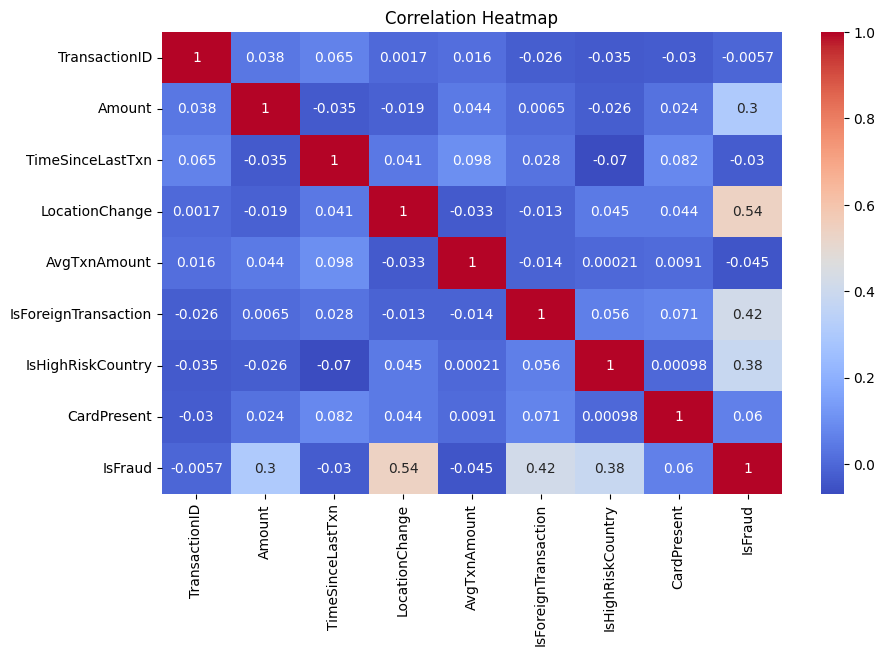

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Selecting features and spliting train-test data for logistic regression

In [4]:
X=df.drop(["TransactionID","IsFraud"], axis=1)
y=df["IsFraud"]


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)


Standardizing features

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [8]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

#ROC Curve

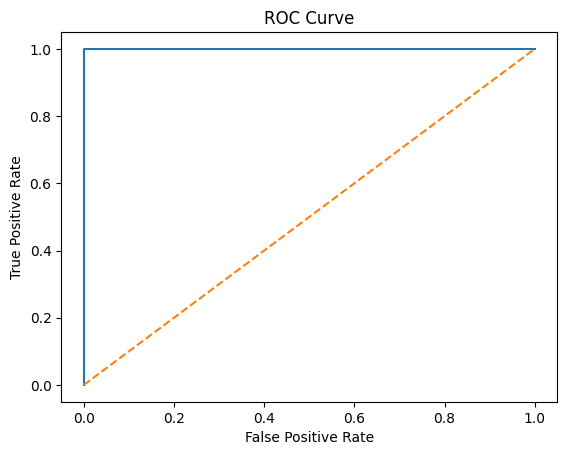

AUC: 1.0


In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr,tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

Coefficient Analysis

In [10]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_[0]):
    print(feature, coef)

Intercept: [-1.71856152]
Amount 2.756232654297564
TimeSinceLastTxn -0.14066440902417623
LocationChange 3.5855756910515
AvgTxnAmount -0.16090898858074526
IsForeignTransaction 3.01151739117318
IsHighRiskCountry 2.4915335554232803
CardPresent 0.03299617645168873


Threshold tune for other value than 0.5

In [11]:
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        63
           1       0.90      1.00      0.95        37

    accuracy                           0.96       100
   macro avg       0.95      0.97      0.96       100
weighted avg       0.96      0.96      0.96       100



L1 and L2 regularization

In [12]:

model_l2 = LogisticRegression(penalty='l2')
model_l2.fit(X_train, y_train)


model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

print("L2 Coefficients:", model_l2.coef_)
print("L1 Coefficients:", model_l1.coef_)

L2 Coefficients: [[ 2.75623265 -0.14066441  3.58557569 -0.16090899  3.01151739  2.49153356
   0.03299618]]
L1 Coefficients: [[ 4.53288011 -0.07872614  5.59289188 -0.13067182  4.73729235  4.02707271
   0.        ]]


In [13]:
print("Default Accuracy:", model.score(X_test, y_test))
print("L1 Accuracy:", model_l1.score(X_test, y_test))
print("L2 Accuracy:", model_l2.score(X_test, y_test))

Default Accuracy: 0.98
L1 Accuracy: 0.99
L2 Accuracy: 0.98


In [14]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[61  2]
 [ 0 37]]


#Interpretations
How do you interpret coefficients? ---Features like LocationChange, IsForeignTransaction, and IsHighRiskCountry are the strongest indicators of fraud, while features like TimeSinceLastTxn and AvgTxnAmount help reduce false alarms by identifying normal behavior.

what happens if two features are highly correlated?
---it leads to multicollinearity, which makes the model unstable and difficult to interpret, to handle this, above we have used regularization L1 and L2.

Comparing L1 and L2---in the above results we can see L1 has performed slightly better than L2,indicating that removing less important features helped improve performance.